# Flag Algebras in Practice: A Zászló Tutorial

**Zászló** is a Python library implementing the *flag algebra method* for extremal combinatorics.
Starting from a problem specification — which graphs are forbidden, what density to bound? — it
enumerates combinatorial structures, builds a semidefinite program (SDP), solves it, and
verifies the certificate in exact rational arithmetic.

This tutorial works through four problems:

1. **Mantel's theorem** — maximum edge density in triangle-free graphs is $\frac{1}{2}$
2. **Rational certificates** — rounding a floating-point SDP solution into a formal proof
3. **The pentagon problem** — maximum $C_5$ density in triangle-free graphs is $\frac{24}{625}$
4. **$K_4^-$-free 3-graphs** — maximum edge density in $K_4^-$-free 3-uniform hypergraphs is $\frac{1}{3}$

## Getting Set Up

Run the cell below to load everything we need. Click it and press **Shift+Enter** — you'll do the same for every code cell throughout.

In [38]:
from fractions import Fraction

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from IPython.display import display

from zaszlo import (
    FlagProblem,
    Hypergraph,
    build_flag_algebra_data,
    certify,
    identify_sharps,
    k4_minus,
    round_certificate,
    solve_sdp,
    verify_certificate,
)

plt.rcParams.update({"figure.dpi": 100})

The two helpers below draw grids of graphs and hypergraphs. They're used throughout for visualization — gold nodes (marked ★) indicate sharp, i.e. extremal, graphs.

In [39]:
def draw_k2_graphs(graphs, densities=None, sharps=None, ncols=4, suptitle=None):
    n = len(graphs)
    if n == 0:
        return
    ncols = min(ncols, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.6 * ncols, 2.6 * nrows))
    flat = np.array(axes).reshape(-1)
    for i, g in enumerate(graphs):
        ax = flat[i]
        G = nx.Graph()
        G.add_nodes_from(range(1, g.n + 1))
        G.add_edges_from(g.edges)
        is_sharp = sharps is not None and i in sharps
        nx.draw(
            G, nx.circular_layout(G), ax=ax, with_labels=True,
            node_color="#F5A623" if is_sharp else "#4A90D9",
            node_size=420, font_size=9, font_color="white",
            edge_color="#444", width=2,
        )
        label = f"d = {densities[i]}" if densities is not None else f"H{i}"
        if is_sharp:
            label += "  ★"
        ax.set_title(label, fontsize=8, pad=3,
                     color="#C05000" if is_sharp else "#333")
    for j in range(n, len(flat)):
        flat[j].set_visible(False)
    if suptitle:
        fig.suptitle(suptitle, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()


def draw_k3_hypergraphs(graphs, densities=None, sharps=None, ncols=4, suptitle=None):
    n = len(graphs)
    if n == 0:
        return
    ncols = min(ncols, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.6 * ncols, 2.6 * nrows))
    flat = np.array(axes).reshape(-1)
    for i, g in enumerate(graphs):
        ax = flat[i]
        is_sharp = sharps is not None and i in sharps
        face = "#F5A623" if is_sharp else "#4A90D9"
        n_v = g.n
        angles = [2 * np.pi * v / n_v - np.pi / 2 for v in range(n_v)]
        pos = {v + 1: (np.cos(angles[v]), np.sin(angles[v])) for v in range(n_v)}
        for edge in g.edges:
            tri = plt.Polygon(
                [pos[v] for v in edge], alpha=0.4,
                facecolor=face, edgecolor="#333", lw=1.2,
            )
            ax.add_patch(tri)
        for v, (x, y) in pos.items():
            ax.plot(x, y, "o", color="#111", ms=7, zorder=3)
            ax.text(x * 1.38, y * 1.38, str(v),
                    ha="center", va="center", fontsize=9, zorder=4)
        ax.set(xlim=(-1.7, 1.7), ylim=(-1.7, 1.7), aspect="equal")
        ax.set_axis_off()
        label = f"d = {densities[i]}" if densities is not None else f"H{i}"
        if is_sharp:
            label += "  ★"
        ax.set_title(label, fontsize=8, pad=3,
                     color="#C05000" if is_sharp else "#333")
    for j in range(n, len(flat)):
        flat[j].set_visible(False)
    if suptitle:
        fig.suptitle(suptitle, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

---
## Background: The Flag Algebra Method

The flag algebra method (Razborov, 2007) turns extremal combinatorics questions into semidefinite
programs. Here is the 60-second version.

**The setting.** We want to bound the density of a target pattern $H$ in large graphs that avoid a
forbidden subgraph $F$. The *density* $p(H; G)$ is the probability that a uniformly random
$|V(H)|$-subset of $V(G)$ induces a copy of $H$.

**The averaging identity.** A *type* $\sigma$ is a small fully-labeled $k$-graph. A *flag* over
$\sigma$ is a larger graph whose first $s$ vertices replicate $\sigma$ exactly; the remaining
vertices are *unlabeled* and averaged over all embeddings. For any large admissible graph $G$,
the probability of a random extension landing on flag pair $(f_i, f_j)$ is the *pair density*
$p(f_i, f_j; G)$ — a linear function of the subgraph densities of $G$.

**The SDP.** For any positive semidefinite matrices $\{Q_\sigma\}$, the quantity
$$\sum_{\sigma}\sum_{i,j} (Q_\sigma)_{ij}\, p(f_i^\sigma, f_j^\sigma; G) \;\ge\; 0$$
is non-negative. So if we find $\{Q_\sigma\}$ and $\lambda$ with
$$\lambda - p(H; G) = \sum_\sigma \langle Q_\sigma, P_\sigma(H) \rangle \ge 0$$
for every admissible $H$, then $p(H; G) \le \lambda$ for all admissible $G$.
Minimizing $\lambda$ subject to these constraints is a semidefinite program.

**The Zászló workflow:**
```
data   = build_flag_algebra_data(prob)    # enumerate structures, compute pair densities
result = solve_sdp(data, extract_Q=True) # find optimal PSD certificate
proof  = certify(result)                 # round + verify; returns a Certificate
sharps = identify_sharps(data, result)   # find sharp (tight-constraint) graphs
```

---
## 1. Mantel's Theorem

**Theorem (Mantel, 1907).** A triangle-free graph on $n$ vertices has at most
$\lfloor n^2/4 \rfloor$ edges. Equivalently, its edge density satisfies
$p(K_2; G) \le \frac{1}{2}$, with equality for the balanced complete bipartite graph
$K_{\lfloor n/2\rfloor,\lceil n/2\rceil}$.

We'll recover the bound $\frac{1}{2}$ via flag algebras at order $n = 4$.

### Defining the problem

First, the forbidden graph: $K_3$, the triangle. We construct it by supplying the vertex count,
edge uniformity ($k = 2$ for ordinary graphs), and the edge list. Vertices in Zászló are 1-based.

In [40]:
K3 = Hypergraph(3, 2, [(1, 2), (1, 3), (2, 3)])
K3

Hypergraph(n=3, k=2, edges=[(1, 2), (1, 3), (2, 3)])

Every Zászló object renders as an annotated HTML card in Jupyter — just put it on the last line
of a cell. For a richer plain-text description that works anywhere (scripts, REPLs, notebooks),
call `.explain()`. We'll use both throughout.

Now let's encode the optimization problem. `FlagProblem` bundles all the parameters the library
needs to build and solve the SDP.

In [41]:
prob_mantel = FlagProblem(
    4,              # n: admissible graphs on 4 vertices
    2,              # type_order: types of order 0 and 2 (same parity as n=4)
    2,              # k: ordinary graphs (2-uniform)
    forbidden=[K3], # forbid non-induced K3
    minimize=False, # upper bound mode: minimize lambda
)
prob_mantel

FlagProblem(n=4, type_order=2, k=2, minimize=False)

### Parameters explained

| Parameter | Value | Meaning |
|---|---|---|
| `n` | 4 | Admissible graphs (the "test objects") live on 4 vertices |
| `type_order` | 2 | Use types of order 0 and 2; must share parity with $n$ |
| `k` | 2 | Ordinary graphs (edges have size 2) |
| `forbidden` | `[K3]` | No non-induced copy of $K_3$ is allowed |
| `minimize` | `False` | Upper bound mode: minimize $\lambda$ |

For a type of order $s$, flags live on $m = \frac{n+s}{2}$ vertices. With $n = 4$:

- Order-$0$ type → flags on $m = 2$ vertices
- Order-$2$ types → flags on $m = 3$ vertices

Larger $n$ and `type_order` give tighter bounds at the cost of a bigger SDP.
`type_order = n - 2` is the standard choice.

### Building the flag algebra data

`build_flag_algebra_data` enumerates all non-isomorphic types, flags, and admissible graphs
consistent with the problem, then computes the pair density matrices used as SDP constraints.

In [42]:
data_mantel = build_flag_algebra_data(prob_mantel)
data_mantel

Type,Graph,Flags
σ=0,"0v, 2-unif",2
σ=1,"2v, 2-unif",4
σ=2,"2v, 2-unif",3


In [43]:
print(data_mantel.explain())

FlagAlgebraData  (pre-SDP combinatorial data)

  Types:             3  (one Q matrix / SDP block each)
  Flags per type:    [2, 4, 3]  (9 total)
  Admissible graphs: 7  (objects whose densities are bounded)
  Density range:     [0.0000, 0.6667]

This is the input to the SDP solver. The solver searches for PSD
matrices Q_σ (one per type σ) satisfying, for every admissible H:

  bound − density(H)  =  Σ_σ ⟨Q_σ, P_σ(H)⟩  +  slack(H)

The PSD matrices Q_σ define a flag-algebra sum-of-squares expression.
Together with the verified coefficient inequalities over admissible
graphs, this yields the stated bound.

  Admissible graphs — the feasible graphs on n vertices; the SDP
    bounds their density.  Forbidden subgraphs have already been
    filtered out.
  Types — all-labeled graphs; each type σ indexes one SDP block Q_σ.
  Flags — graphs with a type embedded; pairs of flags over σ average
    to admissible densities, giving the constraint matrix P_σ(H).


### Admissible graphs

All 7 non-isomorphic triangle-free graphs on 4 vertices. These are the objects the flag algebra
"sees" — any triangle-free graphon decomposes into a mixture of their densities.

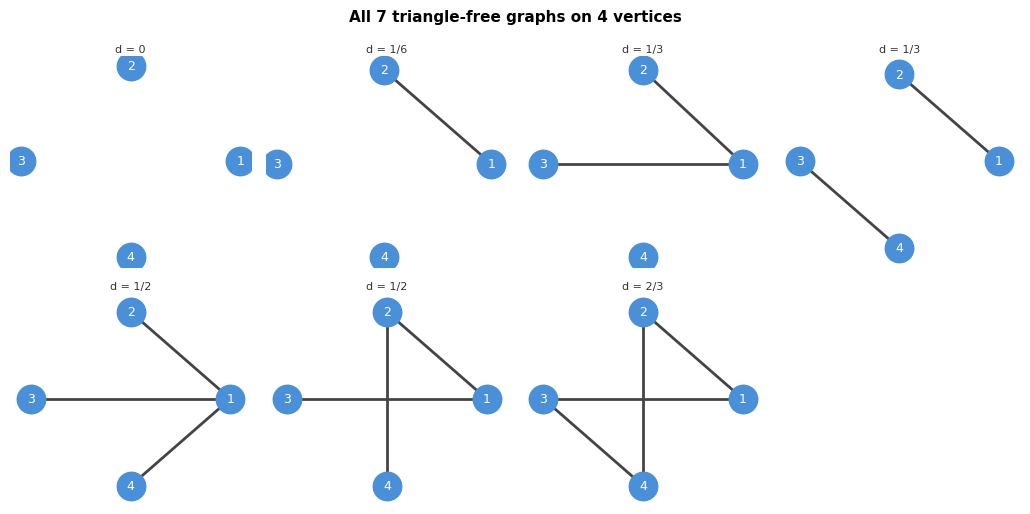

In [44]:
draw_k2_graphs(
    data_mantel.admissible,
    densities=data_mantel.densities,
    suptitle="All 7 triangle-free graphs on 4 vertices",
)

### Types and flags

A **type** of order $s$ is a fully-labeled $k$-graph on $s$ vertices. In Zászló's HTML rendering,
labeled (fixed) vertices are shown in **orange** and unlabeled (averaged) vertices in **blue**.

A **flag** over type $\sigma$ is a graph on $m$ vertices whose first $s$ vertices replicate
$\sigma$ exactly; the remaining $m - s$ unlabeled vertices are averaged over all embeddings into a
large host graph $G$. That averaging turns flag products into linear constraints on subgraph densities.

In [45]:
# Type 2: the single edge {1,2} -- both vertices labeled (orange)
display(data_mantel.types[2])

# A flag over type 2: vertex 3 is unlabeled (blue) and gets averaged
f = data_mantel.flags[2][1]
display(f)
print(f.explain())

Type: 2v 2-uniform hypergraph, 1 edges

Flag over 2-vertex type: 3v 2-uniform hypergraph, 2 edges

Flag  [flag]  n=3, k=2, type_size=2

Labeled vertices:   [1, 2]  (fixed in the host graph)
Unlabeled vertices: [3]  (averaged over all embeddings)

When two flags over the same type are multiplied and the unlabeled
vertices averaged, the result is a density of an admissible graph.

Edges: {1,2}  {1,3}


### Solving the SDP

`solve_sdp` uses Clarabel to find the optimal $\lambda$ and PSD matrices $\{Q_\sigma\}$.
Pass `extract_Q=True` to keep the certificate matrices for later verification.

In [46]:
result_mantel = solve_sdp(data_mantel, extract_Q=True)
print(result_mantel.explain())

FlagAlgebraResult

  Bound  : 0.50000000  (upper bound)
  Status : optimal

Proof claim: Every graph avoiding the 1 forbidden pattern(s) has edge density ≤ 0.500000.

Sharp graphs (active constraints):
  3 graph(s) with near-zero SDP slack.
  These graphs have tight certificate constraints. Note: zero slack
  does not by itself mean a graph attains the density bound.

    [0]  4v 2-uniform hypergraph, 0 edges  (density = 0.0000)
    [4]  4v 2-uniform hypergraph, 3 edges  (density = 0.5000)
    [6]  4v 2-uniform hypergraph, 4 edges  (density = 0.6667)

Proof certificate:
  The bound is certified by PSD matrices Q_σ, one per type σ.
  For every admissible H the following identity holds and is ≥ 0:

    bound − density(H)  =  Σ_σ ⟨Q_σ, P_σ(H)⟩  +  slack(H)

  where:
    P_σ(H) — pair density matrix of H over type σ
    Q_σ    — PSD certificate matrix (one per type, found by SDP)
    ⟨A, B⟩ — matrix inner product  Σ_{ij} A_{ij} B_{ij}

  The PSD matrices Q_σ define a flag-algebra sum-of-sq

### Getting a certificate

`certify()` rounds the floating-point SDP output to exact rational arithmetic and verifies it in one call, returning a `Certificate` object. Internally it:

1. **Rounds** $Q_\sigma$ via Cholesky factorization — ensuring the result is PSD by construction (see Section 2 for details)
2. **Recomputes residuals** exactly: $\lambda - \mathrm{density}(H) - \sum_\sigma \langle Q_\sigma, P_\sigma(H)\rangle$ for each admissible $H$
3. **Sets `valid = True`** iff all residuals are $\ge 0$

`valid: True` on the raw float result is not guaranteed — see Section 2 for why rounding is needed before the certificate counts as a proof.

In [47]:
proof_mantel = certify(result_mantel)
print(f"Bound (exact)  : {proof_mantel.bound}")
print(f"Valid          : {proof_mantel.valid}")
print(f"Active constraints: {proof_mantel.active_constraints}")

Bound (exact)  : 24834471153474084/49668769112077837
Valid          : True
Active constraints: [4]


### Sharp (extremal) graphs

An admissible graph $H$ is *sharp* when its SDP slack is zero: the bound is tight at $H$.
Sharp graphs reveal the extremal structure — for Mantel, the extremal graphon is the balanced
bipartite graphon ($K_{n/2,n/2}$ in the limit), so locally one sees $C_4 = K_{2,2}$ and all
its subgraphs.

In [48]:
sharps_mantel = identify_sharps(data_mantel, result_mantel)
sharps_mantel

SharpsResult  3 sharp graph(s)  (n=4, k=2)

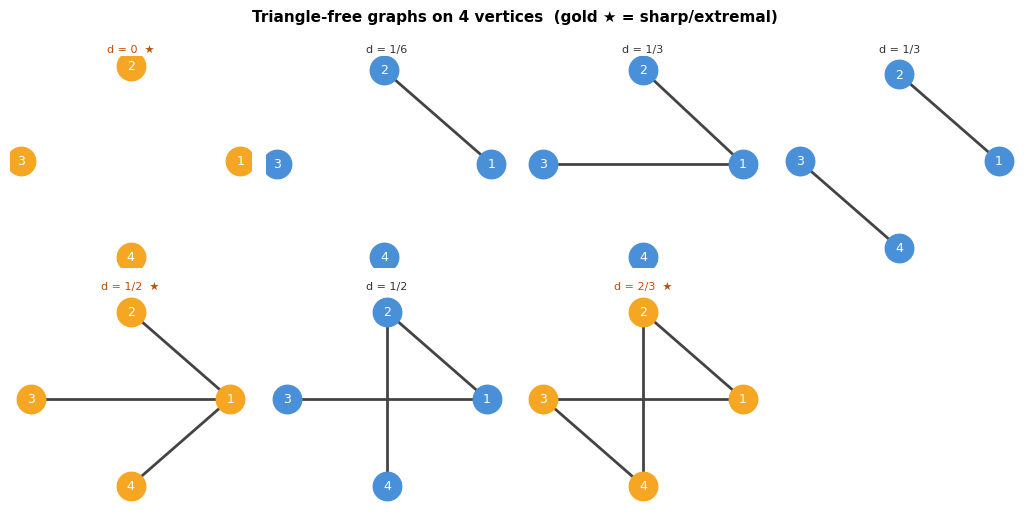

In [49]:
draw_k2_graphs(
    data_mantel.admissible,
    densities=data_mantel.densities,
    sharps=set(sharps_mantel.indices),
    suptitle="Triangle-free graphs on 4 vertices  (gold ★ = sharp/extremal)",
)

---
## 2. Under the Hood: `round_certificate` and `verify_certificate`

`certify()` is a convenience wrapper. This section walks through what it does internally, so you understand the guarantees and can tune `denom_limit` if needed.

The SDP solver returns floating-point $Q$ matrices. Verifying these directly shows why rounding is necessary — residuals may be slightly negative at the level of solver tolerance, so `valid` may be `False` even when the bound is numerically correct. This is expected.

To produce a certificate that constitutes a **genuine mathematical proof**, we need exact rational $Q_\sigma$ matrices that are provably PSD and satisfy all constraints. `round_certificate` does this in three steps for each $Q_\sigma$:

1. **Cholesky factor**: decompose $Q_\sigma \approx L L^\top$ where $L$ is lower triangular.
2. **Round $L$**: replace each entry with the nearest rational having denominator $\le D$
   (controlled by `denom_limit`, default $D = 1000$), in exact `Fraction` arithmetic.
3. **Reconstruct**: form $\tilde{Q}_\sigma = \tilde{L}\,\tilde{L}^\top$ exactly — so
   $\tilde{Q}_\sigma \succeq 0$ by construction.

Because rounding changes the flag sums, `round_certificate` recomputes the certified bound
$\lambda_{\rm cert}$ as the tightest $\lambda$ the rounded $Q$ matrices actually prove.
It's slightly weaker than the solver's bound, but honest and independently checkable.

### Step 1 — the raw certificate

We already computed `result_mantel` above. Verifying it directly shows the `valid: False` baseline.

In [50]:
cert_raw = verify_certificate(data_mantel, result_mantel)
print(f"valid          : {cert_raw['valid']}")
print(f"min_residual   : {float(cert_raw['min_residual']):.2e}  <- tiny float noise")
print(f"min_psd_eigval : {cert_raw['min_psd_eigval']:.2e}")
print(f"lam_certified  : {cert_raw['lam_certified']}")

valid          : False
min_residual   : -3.84e-09  <- tiny float noise
min_psd_eigval : -1.06e-09
lam_certified  : 1/2


### Step 2 — round to exact rationals

`denom_limit=1000` means each Cholesky factor entry is rounded to the nearest rational with
denominator at most 1000. Larger values give a tighter certified bound at the cost of bigger numerators.

In [51]:
result_mantel_rat = round_certificate(data_mantel, result_mantel, denom_limit=1000)

print(f"Original bound : {result_mantel.bound:.10f}  (float)")
print(f"Certified bound: {result_mantel_rat.bound_exact}")
print(f"               = {float(result_mantel_rat.bound_exact):.10f}  (slightly above 1/2; closes with larger denom_limit)")

Original bound : 0.5000000029  (float)
Certified bound: 24834471153474084/49668769112077837
               = 0.5000017435  (slightly above 1/2; closes with larger denom_limit)


### Step 3 — verify the rounded certificate

With $\tilde Q_\sigma = \tilde L \tilde L^\top$ exact in `Fraction` arithmetic, every
residual is now non-negative exactly, and `valid` is `True`.

In [52]:
cert_rat = verify_certificate(data_mantel, result_mantel_rat)
print(f"valid          : {cert_rat['valid']}")
print(f"lam_certified  : {cert_rat['lam_certified']}")
print(f"min_residual   : {cert_rat['min_residual']}  (exact zero)")
print()
print("Residuals per admissible graph:")
for i, (H, r) in enumerate(zip(data_mantel.admissible, cert_rat["residuals"])):
    status = "\u2713" if r >= 0 else "\u2717"
    print(f"  H{i}  ({len(H.edges)} edges)  residual = {r}  {status}")

valid          : True
lam_certified  : 24834471153474084/49668769112077837
min_residual   : 0  (exact zero)

Residuals per admissible graph:
  H0  (0 edges)  residual = 126871737323969/39685346520550191763  ✓
  H1  (1 edges)  residual = 5245760856203113056121156406/26390605862094841568722245253  ✓
  H2  (2 edges)  residual = 69383817304921190130779006626009523/401917406081350386312452196965896956  ✓
  H3  (2 edges)  residual = 179727972817280993298107767784893/905414157614286837155253987683097  ✓
  H4  (3 edges)  residual = 0  ✓
  H5  (3 edges)  residual = 119551324424260799818514954/1022511107086754924335196337  ✓
  H6  (4 edges)  residual = 483555973018376/135148720753963794477  ✓


In [53]:
print(proof_mantel.explain())

Certificate  [VALID]  (upper bound)

  Certified bound : 24834471153474084/49668769112077837  =  0.50000174
  Valid           : True
  Admissible graphs: 7

The PSD matrices Q_σ define a flag-algebra sum-of-squares expression.
Together with the verified coefficient inequalities over admissible
graphs, this yields the stated bound.

Active constraints — 1 graph(s) with residual = 0:
  [4]  4v 2-uniform hypergraph, 3 edges   density = 1/2

PSD certificate matrices (3 total, one per type):
  Q[0]  2×2  (rational entries, PSD by construction)
  Q[1]  4×4  (rational entries, PSD by construction)
  Q[2]  3×3  (rational entries, PSD by construction)


### The full proof pipeline

`certify()` wraps `round_certificate` and `verify_certificate` into a single call, returning a `Certificate` object with exact rational $Q_\sigma$ matrices, a certified bound, per-graph residuals, and a validity flag.

```python
data   = build_flag_algebra_data(prob)
result = solve_sdp(data, extract_Q=True)
proof  = certify(result)    # round + verify; Certificate with exact Fraction arithmetic
assert proof.valid          # proof complete
sharps = identify_sharps(data, result)  # find sharp (tight-constraint) graphs
```

**Two paths, two guarantees.**

| Path | Bound | Residuals | Proof? |
|------|-------|-----------|--------|
| Raw float output | solver bound (e.g. $1/2$) | may be $\sim{-10^{-9}}$ (float noise) | No |
| `certify(result)` | $\lambda_{\rm cert}$ (slightly weaker) | all $\ge 0$ exactly | Yes |

**Note on `denom_limit`.** `certify` accepts a `denom_limit` keyword (default 1000) that controls rounding precision. Larger values give a tighter certified bound at the cost of bigger numerators.

---
## 3. The Pentagon Problem

**Problem.** Among all triangle-free graphs, what is the maximum density of 5-cycles ($C_5$)?

**Answer** (Grzesik, 2012; Hatami–Hladký–Král’–Norine–Razborov, 2013):
$\dfrac{24}{625} = 0.0384$.

The extremal construction is the *balanced blow-up of $C_5$*: replace each vertex of $C_5$ by an
equal-size independent set and connect consecutive parts completely. In the limit this achieves
exactly $\frac{24}{625}$.

The new ingredient here is the `target` parameter, which tells Zászló to optimize the density of
a specific pattern rather than edge density. We also raise $n$ to 5 and `type_order` to 3 to get
the tight bound.

**Note on induced vs. non-induced.** In a triangle-free graph every $C_5$ is automatically
induced — any chord would close a triangle — so the $C_5$ density and induced $C_5$ density
coincide here, and `target=C5` (which computes induced density) is correct without qualification.

In [54]:
C5 = Hypergraph(5, 2, [(1, 2), (2, 3), (3, 4), (4, 5), (5, 1)])
C5

Hypergraph(n=5, k=2, edges=[(1, 2), (1, 5), (2, 3), (3, 4), (4, 5)])

In [55]:
prob_c5 = FlagProblem(
    5,              # n=5: work at order 5
    3,              # type_order=3 (same parity as 5; flags on (5+3)/2=4 vertices)
    2,              # k=2: ordinary graphs
    forbidden=[K3], # still triangle-free
    target=C5,      # maximize C5 density, not edge density
    minimize=False,
)
prob_c5

FlagProblem(n=5, type_order=3, k=2, minimize=False)

In [56]:
data_c5 = build_flag_algebra_data(prob_c5)
print(data_c5.explain())

FlagAlgebraData  (pre-SDP combinatorial data)

  Types:             4  (one Q matrix / SDP block each)
  Flags per type:    [5, 8, 6, 5]  (24 total)
  Admissible graphs: 14  (objects whose densities are bounded)
  Density range:     [0.0000, 1.0000]

This is the input to the SDP solver. The solver searches for PSD
matrices Q_σ (one per type σ) satisfying, for every admissible H:

  bound − density(H)  =  Σ_σ ⟨Q_σ, P_σ(H)⟩  +  slack(H)

The PSD matrices Q_σ define a flag-algebra sum-of-squares expression.
Together with the verified coefficient inequalities over admissible
graphs, this yields the stated bound.

  Admissible graphs — the feasible graphs on n vertices; the SDP
    bounds their density.  Forbidden subgraphs have already been
    filtered out.
  Types — all-labeled graphs; each type σ indexes one SDP block Q_σ.
  Flags — graphs with a type embedded; pairs of flags over σ average
    to admissible densities, giving the constraint matrix P_σ(H).


With `target=C5`, the **density of each admissible graph** is now its induced $C_5$ density. The
14 admissible triangle-free graphs on 5 vertices are shown below — most have zero $C_5$ density,
with the full 5-cycle being the only one that achieves $d = 1$.

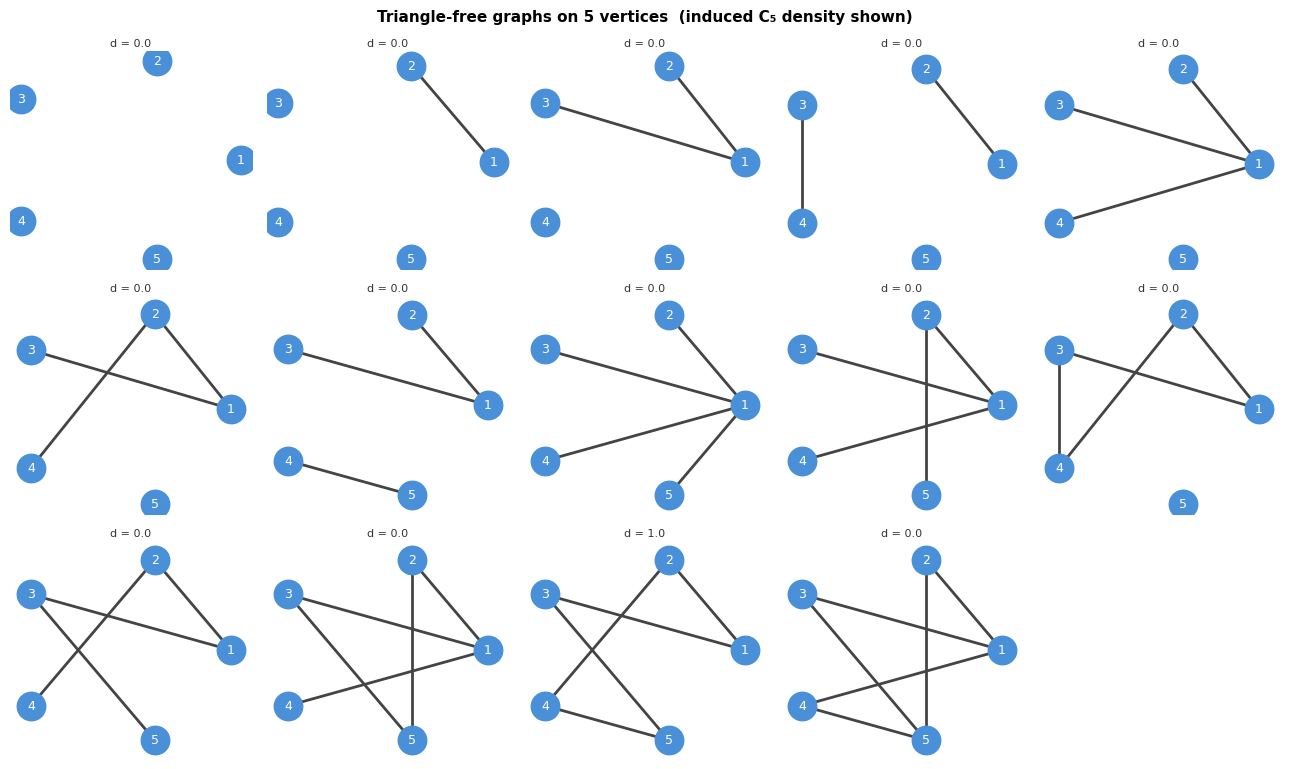

In [57]:
c5_dens_float = [round(float(d), 4) for d in data_c5.densities]
draw_k2_graphs(
    data_c5.admissible,
    densities=c5_dens_float,
    ncols=5,
    suptitle="Triangle-free graphs on 5 vertices  (induced C₅ density shown)",
)

In [58]:
result_c5 = solve_sdp(data_c5, extract_Q=True)
cert_c5 = certify(result_c5)
print(result_c5.explain())
print(f"Known exact: {Fraction(24, 625)}  =  {24/625:.6f}")

FlagAlgebraResult

  Bound  : 0.03840001  (upper bound)
  Status : optimal

Proof claim: Every graph avoiding the 1 forbidden pattern(s) has target density ≤ 0.038400.

Sharp graphs (active constraints):
  10 graph(s) with near-zero SDP slack.
  These graphs have tight certificate constraints. Note: zero slack
  does not by itself mean a graph attains the density bound.

    [0]  5v 2-uniform hypergraph, 0 edges  (density = 0.0000)
    [1]  5v 2-uniform hypergraph, 1 edges  (density = 0.0000)
    [2]  5v 2-uniform hypergraph, 2 edges  (density = 0.0000)
    [4]  5v 2-uniform hypergraph, 3 edges  (density = 0.0000)
    [7]  5v 2-uniform hypergraph, 4 edges  (density = 0.0000)
    [8]  5v 2-uniform hypergraph, 4 edges  (density = 0.0000)
    [9]  5v 2-uniform hypergraph, 4 edges  (density = 0.0000)
    [11]  5v 2-uniform hypergraph, 5 edges  (density = 0.0000)
    [12]  5v 2-uniform hypergraph, 5 edges  (density = 1.0000)
    [13]  5v 2-uniform hypergraph, 6 edges  (density = 0.0000)

Pr

In [59]:
sharps_c5 = identify_sharps(data_c5, result_c5)
sharps_c5

SharpsResult  10 sharp graph(s)  (n=5, k=2)

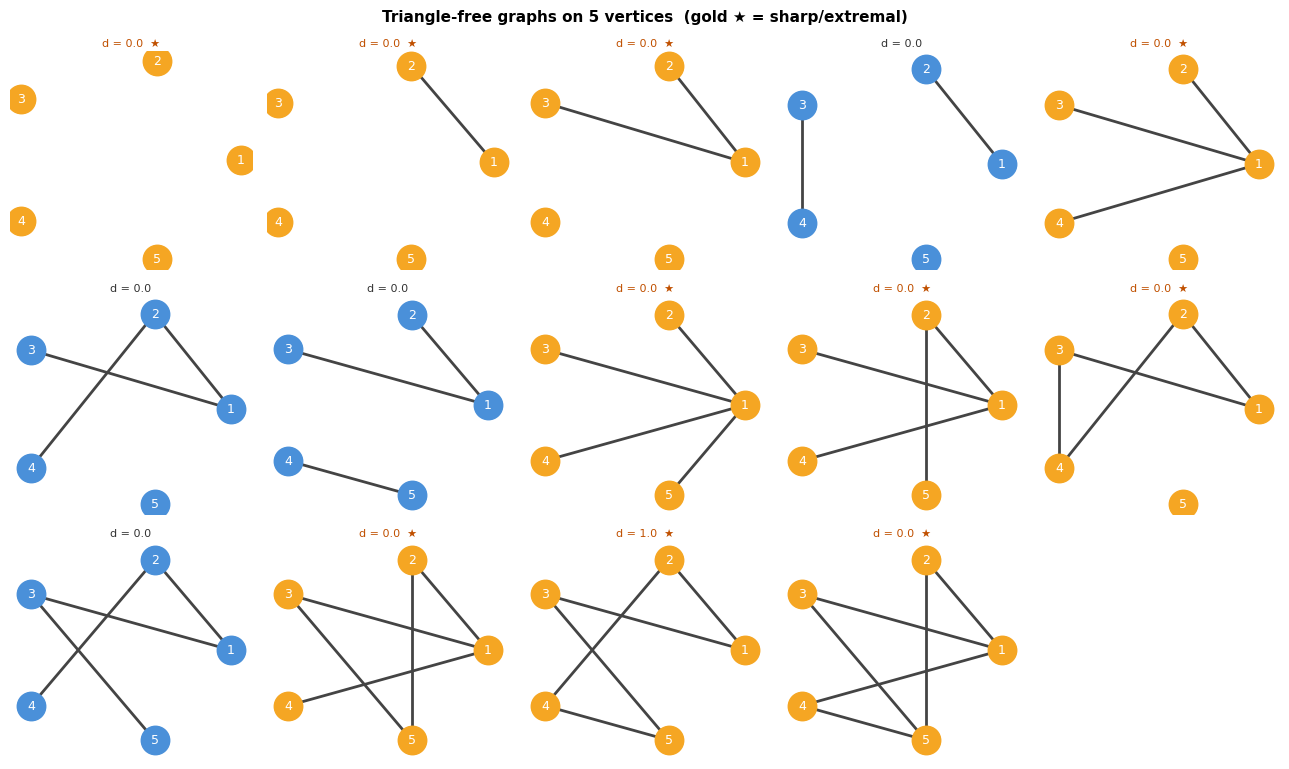

In [60]:
draw_k2_graphs(
    data_c5.admissible,
    densities=c5_dens_float,
    sharps=set(sharps_c5.indices),
    ncols=5,
    suptitle="Triangle-free graphs on 5 vertices  (gold ★ = sharp/extremal)",
)

---
## 4. $K_4^-$-Free 3-Uniform Hypergraphs

**Generalization to hypergraphs.** In a *$k$-uniform hypergraph* every edge has exactly $k$
vertices. Flag algebras apply unchanged — just set `k=3`.

**The forbidden pattern.** $K_4^-$ is the unique (up to isomorphism) 3-uniform hypergraph on
4 vertices with exactly 3 edges (one edge is missing from the complete $K_4^{(3)}$):
$$K_4^- = \bigl\{\{1,2,3\},\, \{1,2,4\},\, \{1,3,4\}\bigr\}$$

**The question.** What is the maximum edge density of a $K_4^-$-free 3-uniform hypergraph?

**Answer** (Frankl–Füredi conjecture; Keevash–Sudakov, 2005): $\dfrac{1}{3}$.
The extremal construction partitions the vertex set into 3 equal parts and includes all triples
that have at least two vertices in one part.

The built-in `k4_minus()` shorthand constructs this graph.

In [61]:
K4m = k4_minus()
K4m

Hypergraph(n=4, k=3, edges=[(1, 2, 3), (1, 2, 4), (1, 3, 4)])

In [62]:
print(K4m.explain())

Hypergraph  n=4, k=3, 3 edges

Edges: {1,2,3}  {1,2,4}  {1,3,4}

Edge density: 3/4 = 0.7500  (3/4)

This is a 3-uniform hypergraph: every edge is a triple of vertices.


In [63]:
prob_k4m = FlagProblem(
    5,               # n=5
    3,               # type_order=3 (same parity as 5)
    3,               # k=3: 3-uniform hypergraphs
    forbidden=[K4m],
    minimize=False,
)
prob_k4m

FlagProblem(n=5, type_order=3, k=3, minimize=False)

In [64]:
data_k4m = build_flag_algebra_data(prob_k4m)
print(data_k4m.explain())

FlagAlgebraData  (pre-SDP combinatorial data)

  Types:             3  (one Q matrix / SDP block each)
  Flags per type:    [2, 7, 4]  (13 total)
  Admissible graphs: 11  (objects whose densities are bounded)
  Density range:     [0.0000, 0.5000]

This is the input to the SDP solver. The solver searches for PSD
matrices Q_σ (one per type σ) satisfying, for every admissible H:

  bound − density(H)  =  Σ_σ ⟨Q_σ, P_σ(H)⟩  +  slack(H)

The PSD matrices Q_σ define a flag-algebra sum-of-squares expression.
Together with the verified coefficient inequalities over admissible
graphs, this yields the stated bound.

  Admissible graphs — the feasible graphs on n vertices; the SDP
    bounds their density.  Forbidden subgraphs have already been
    filtered out.
  Types — all-labeled graphs; each type σ indexes one SDP block Q_σ.
  Flags — graphs with a type embedded; pairs of flags over σ average
    to admissible densities, giving the constraint matrix P_σ(H).


### Visualizing 3-uniform hypergraphs

Each hyperedge (a triple of vertices) is drawn as a filled triangle. The 11 admissible graphs
below are all $K_4^-$-free 3-uniform hypergraphs on 5 vertices.

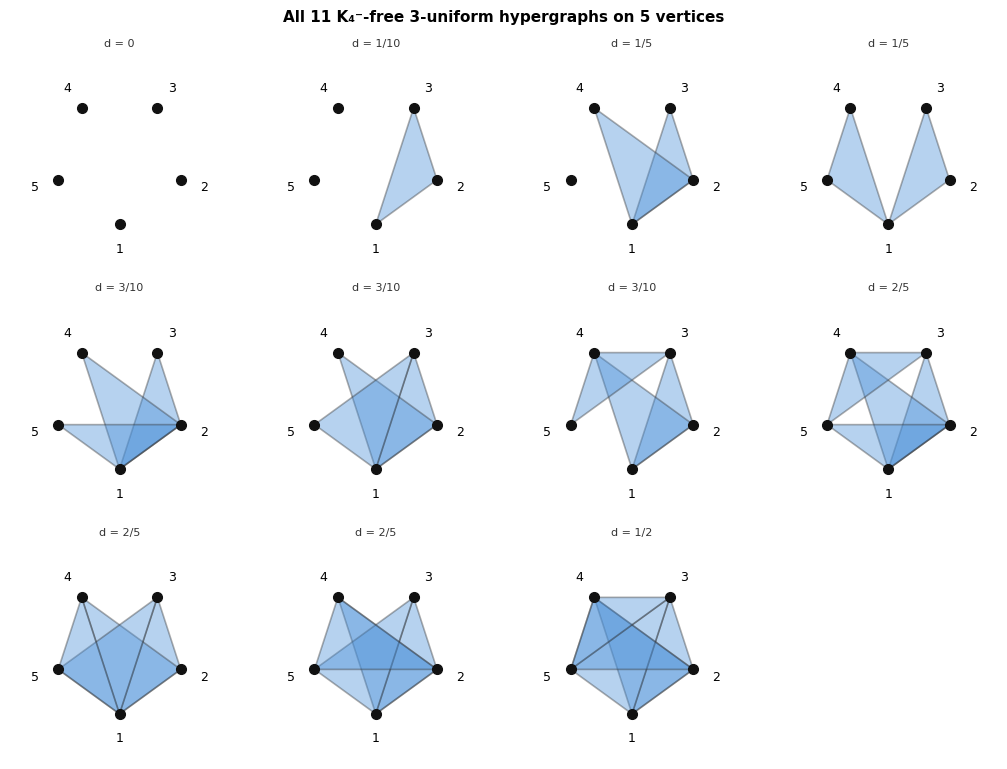

In [65]:
draw_k3_hypergraphs(
    data_k4m.admissible,
    densities=data_k4m.densities,
    ncols=4,
    suptitle="All 11 K₄⁻-free 3-uniform hypergraphs on 5 vertices",
)

In [67]:
result_k4m = solve_sdp(data_k4m, extract_Q=True)
print(result_k4m.explain())

FlagAlgebraResult

  Bound  : 0.33333334  (upper bound)
  Status : optimal

Proof claim: Every 3-uniform hypergraph avoiding the 1 forbidden pattern(s) has edge density ≤ 0.333333.

Sharp graphs (active constraints):
  4 graph(s) with near-zero SDP slack.
  These graphs have tight certificate constraints. Note: zero slack
  does not by itself mean a graph attains the density bound.

    [0]  5v 3-uniform hypergraph, 0 edges  (density = 0.0000)
    [4]  5v 3-uniform hypergraph, 3 edges  (density = 0.3000)
    [8]  5v 3-uniform hypergraph, 4 edges  (density = 0.4000)
    [10]  5v 3-uniform hypergraph, 5 edges  (density = 0.5000)

Proof certificate:
  The bound is certified by PSD matrices Q_σ, one per type σ.
  For every admissible H the following identity holds and is ≥ 0:

    bound − density(H)  =  Σ_σ ⟨Q_σ, P_σ(H)⟩  +  slack(H)

  where:
    P_σ(H) — pair density matrix of H over type σ
    Q_σ    — PSD certificate matrix (one per type, found by SDP)
    ⟨A, B⟩ — matrix inner product

In [68]:
cert_k4m = certify(result_k4m)
print(f"Bound (exact)  : {cert_k4m.bound}")
print(f"Valid          : {cert_k4m.valid}")

Bound (exact)  : 4260196307868439043015233/12780306197493730106323200
Valid          : True


In [69]:
sharps_k4m = identify_sharps(data_k4m, result_k4m)
sharps_k4m

SharpsResult  4 sharp graph(s)  (n=5, k=3)

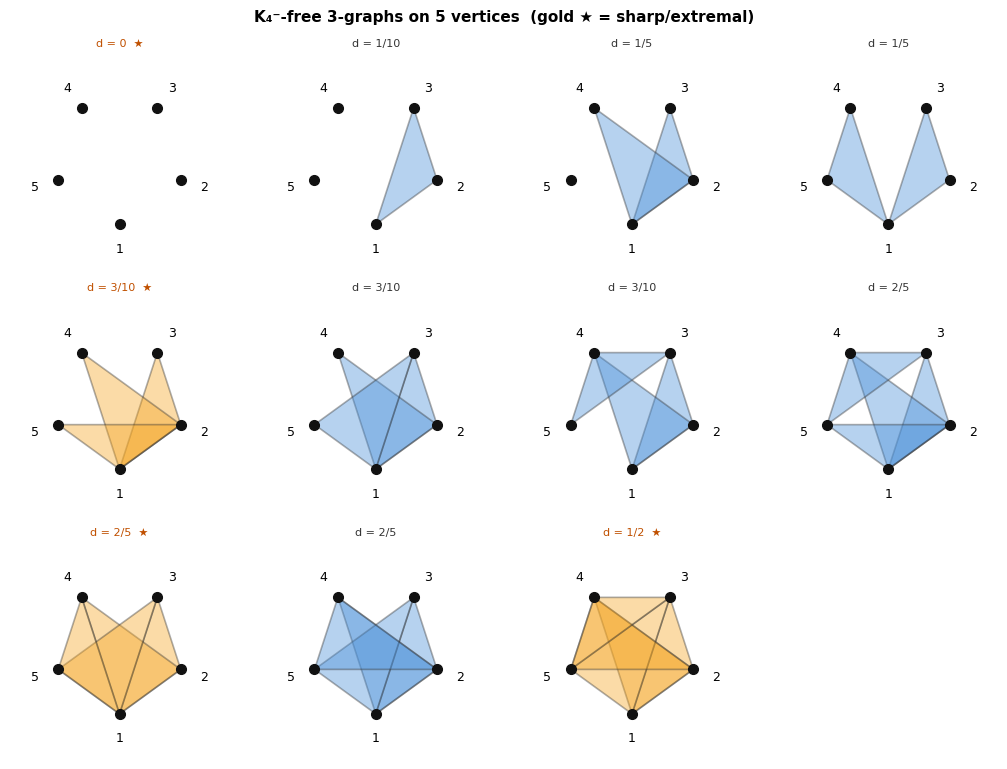

In [70]:
draw_k3_hypergraphs(
    data_k4m.admissible,
    densities=data_k4m.densities,
    sharps=set(sharps_k4m.indices),
    ncols=4,
    suptitle="K₄⁻-free 3-graphs on 5 vertices  (gold ★ = sharp/extremal)",
)

---
## 5. Beyond a single forbidden graph and a single target

The examples so far each forbid one subgraph and optimize the density of one target. Zászló supports two natural generalizations of this shape.

### 5a. Multiple forbidden subgraphs

`forbidden=` and `forbidden_induced=` both accept lists — the admissible class is defined by simultaneously avoiding *every* listed pattern. A graph is admissible iff it contains no non-induced copy of any graph in `forbidden` and no induced copy of any graph in `forbidden_induced`.

As a sanity check: since $K_4$ contains $K_3$, forbidding $\{K_3, K_4\}$ produces the same admissible class as forbidding $\{K_3\}$ alone. The counts below match Mantel exactly.

In [ ]:
from zaszlo import complete

K4 = complete(4)

prob_multi = FlagProblem(
    4, 2, 2,
    forbidden=[K3, K4],   # forbid triangles AND K4s (K3-freeness already implies K4-freeness)
)
data_multi = build_flag_algebra_data(prob_multi)
result_multi = solve_sdp(data_multi)

print(f"Admissible count : {len(data_multi.admissible)}   (matches Mantel's 7)")
print(f"Flag counts      : {[len(fs) for fs in data_multi.flags]}   (matches Mantel's [2, 4, 3])")
print(f"Bound            : {result_multi.bound:.6f}   (matches Mantel's 1/2)")

### 5b. Linear-combination targets: `DensityExpr`

Sometimes the quantity of interest is not the density of a single subgraph but a rational linear combination of several. `DensityExpr` represents such a functional:

$$f(H) \;=\; \sum_i c_i \cdot d(H, G_i)$$

Pass it in place of a bare `Hypergraph` to `FlagProblem.target=`. Coefficients must be `int` or `Fraction` — floats are rejected to keep the certified bound story exact. Note: the constructor is deliberately explicit; there is *no* arithmetic overloading on `Hypergraph` (`2 * K3` would be ambiguous once formal flag-algebra elements are added later).

As a worked example, on triangle-free 4-vertex graphs consider

$$f(H) \;=\; d(H, K_2) \;-\; \tfrac{1}{2}\bigl(1 - d(H, K_2)\bigr) \;=\; \tfrac{3}{2}\,d(H, K_2) - \tfrac{1}{2}.$$

At the Mantel optimum $d(H, K_2) = \tfrac{1}{2}$, this equals $\tfrac{3}{2} \cdot \tfrac{1}{2} - \tfrac{1}{2} = \tfrac{1}{4}$. Since the induced density of the 2-vertex empty graph on $H$ equals $1 - d(H, K_2)$, the expression is naturally written as a two-term `DensityExpr`.

In [ ]:
from zaszlo import DensityExpr

edge     = Hypergraph(2, 2, [(1, 2)])   # K_2
empty_2v = Hypergraph(2, 2, [])          # 2-vertex empty graph

f = DensityExpr([
    (1,               edge),
    (-Fraction(1, 2), empty_2v),
])
print(f.explain())

In [ ]:
prob_lin = FlagProblem(4, 2, 2, forbidden=[K3], target=f)
proof_lin = solve_sdp(build_flag_algebra_data(prob_lin), extract_Q=True)
cert_lin  = certify(proof_lin)

print(f"Certified bound : {cert_lin.bound}  =  {float(cert_lin.bound):.6f}")
print(f"Known optimum   : 1/4              =  0.250000")
print(f"Valid           : {cert_lin.valid}")

---
## Summary

| Example | `k` | `n` | Forbidden | Target | Bound | Reference |
|---|---|---|---|---|---|---|
| Mantel's theorem | 2 | 4 | $K_3$ | edge density | $\frac{1}{2}$ | Mantel (1907) |
| Pentagon density | 2 | 5 | $K_3$ | $C_5$ density | $\frac{24}{625}$ | Grzesik (2012); Hatami et al. (2013) |
| $K_4^-$-free 3-graphs | 3 | 5 | $K_4^-$ | edge density | $\frac{1}{3}$ | Frankl–Füredi / Keevash–Sudakov |

### The proof pipeline

```python
data   = build_flag_algebra_data(prob)          # enumerate structures, compute pair densities
result = solve_sdp(data, extract_Q=True)        # numerical SDP
proof  = certify(result)                        # round + verify; Certificate in exact arithmetic
assert proof.valid                              # proof complete
sharps = identify_sharps(data, result)          # find sharp (tight-constraint) graphs
```

### `FlagProblem` quick reference

```python
FlagProblem(
    n,                       # order of admissible graphs
    type_order,              # max type order; same parity as n, and <= n-2
    k,                       # edge uniformity (k=2: graphs, k=3: 3-uniform, ...)
    forbidden=[...],         # forbid non-induced copies
    forbidden_induced=[...], # forbid induced copies (optional)
    target=H,                # optimize density of H (default: edge density)
    minimize=False,          # False = upper bound, True = lower bound
)
```

### Built-in hypergraph constructors

```python
Hypergraph(n, k, edges)     # general constructor; vertices are 1-based
complete(n, k=2)            # complete k-uniform hypergraph on n vertices
k4_minus()                  # K4-minus: 4-vertex 3-graph with 3 edges
c5_3uniform()               # tight 5-cycle in 3-uniform hypergraphs
f32()                       # F32: 5-vertex 3-graph with 4 edges
```

In [ ]:
rows = [
    ("Mantel",     proof_mantel.bound, Fraction(1, 2)),
    ("C5 density", cert_c5.bound,      Fraction(24, 625)),
    ("K4- free",   cert_k4m.bound,     Fraction(1, 3)),
]
print(f"{'Problem':<14}  {'SDP bound':>18}  {'Known exact':>12}  {'|error|':>10}")
print("-" * 62)
for name, lam_rat, lam_exact in rows:
    err = abs(float(lam_rat) - float(lam_exact))
    print(f"{name:<14}  {float(lam_rat):>18.6f}  {str(lam_exact):>12}  {err:>10.2e}")